<a href="https://colab.research.google.com/github/fleqi/proyecto-mineria/blob/main/hito1/notebooks/informe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Informe - Hito 1
**Seccion**: 1\
**Grupo**:11\
**Integrantes**: David Han,Felipe Cabezas, José Pérez, Mauricio Cáceres,Simón Espinoza P.\


##1.- Introducción: Problema y Motivación

Es un hecho conocido que el cambio climático ha tenido un fuerte impacto en el planeta. Una de las formas que toma este cambio es el calentamiento global, que ha favorecido a un aumento en la frecuencia e intensidad de olas de calor y al desarrollo de sequías. Lo último es particularmente interesante a nivel país, pues estas condiciones favorecen temporadas de incendios más largas/graves, y Chile se ha visto sometida desde hace casi una década y media a una mega sequía con un déficit de lluvia importante donde el promedio de incendios por temporada subió a más de 4000 y el tamaño de los mismos también ha subido.

Lo anterior permite preguntarnos si existe una relación entre el cambio climático y el aumento de incendios forestales en Chile. Si bien las organizaciones señalan que la mayoría tiene un origen humano, lo anterior no quita que hay temporadas de mayores incendios que coincide con los meses más calurosos, haciendo que  nos planteemos si existirá una correlación entre este cambio y el aumento de incendios.

Para este proyecto se ha decidido trabajar con datos climaticos historicos del pais junto con datos de ocurrencias de incendios. Para esto se han extraido tres bases de datos, una que proviene de la [Direccion Meteorologica de Chile](https://github.com/MinCiencia/Datos-CambioClimatico), en el repositorio del observatorio de cambio climatico, y las otras dos bases de datos son de ocurrencias historicas de incendios, una de la CONAF(ocurrencias nacionales) y la otra de la NASA(ocurrencias globales)

Estos datos tienen el potencial de determinar si existe una correlacion entre la gran cantidad de factores climaticos, con los incendios que ocurren en el pais y la severidad/tamaño de los mismos. Se plantea la hipótesis que si bien los incendios son comenzados por personas, la propagación y por consecuencia el tamaño de los mismos es facilitado por condiciones ambientales como la falta de humedad generada por altas temperaturas y/o bajas precipitaciones.

Poder determinar una posible relación y entrenar un modelo con estos factores resulta interesante e importante pues los incendios afectan no solo a nuestra flora y fauna, sino también a las personas y sus condiciones de vida como los incendios en Viña del Mar que tomaron lugar durante los años 2022 y 2024 dejaron a muchas personas damnificadas y varias familias sin hogar; en este último afectó al 34% de la comuna de Viña del Mar y quemando El Jardín Botánico de Viña del Mar en un 90% llegando a extinguir una especie de árbol ([Cidigen](https://www.cigiden.cl/informe-revela-el-alcance-de-los-impactos-causados-por-incendios-en-vina-del-mar/)). Por lo que tener modelos de predicción para estas situaciones sería de gran utilidad para poder preveninr o prepararse frente a situaciones como estas.

#2.- Exploracion de datos

|index|temp\_mean|Año|tmax|tmin|temp\_mean\_art|humedad\_mean|viento\_mean|viento\_max|precip\_mm\_dia|n\_incendios|superficie\_prom\_ha|superficie\_ha|
|---|---|---|---|---|---|---|---|---|---|---|---|---|
|count|157982\.0|157982\.0|157982\.0|157982\.0|157982\.0|157982\.0|157982\.0|157982\.0|157982\.0|157982\.0|157982\.0|157982\.0|
|mean|13\.348803816819498|2010\.2421731589675|17\.827409451709688|7\.5344311377245505|12\.68092029471712|69\.74131597183946|6\.878005835367773|12\.2708251572964|1\.964152878175995|6249\.761536124369|15\.509884101895558|91941\.89997259725|
|std|5\.655457048627537|5\.713516030552377|6\.6080399098992135|5\.436479264097048|5\.4095447331827735|16\.799090769127293|4\.554699214563144|6\.445528973522294|6\.8365978070523825|1047\.2065350801224|23\.77987016626604|124684\.30462312835|
|min|-21\.729166666666668|2000\.0|-14\.1|-27\.7|-19\.95|1\.9583333333333333|0\.0|0\.0|0\.0|4069\.0|2\.031436011904762|10921\.0|
|25%|9\.633333333333333|2005\.0|13\.3|3\.8|9\.05|60\.83653846153847|3\.9583333333333335|8\.0|0\.0|5397\.0|6\.205291863207547|42062\.74|
|50%|13\.4|2011\.0|17\.8|7\.6|12\.75|71\.91666666666667|5\.727272727272728|11\.0|0\.0|6335\.0|9\.815120998045995|58364\.12|
|75%|17\.183333333333334|2015\.0|22\.4|11\.3|16\.5|82\.0|8\.375|15\.0|0\.2|6976\.0|14\.343602850823299|90279\.0|
|max|30\.99|2019\.0|41\.5|24\.6|28\.6|100\.0|39\.16666666666666|70\.0|200\.8|8127\.0|108\.11478843382746|570197\.394200006|

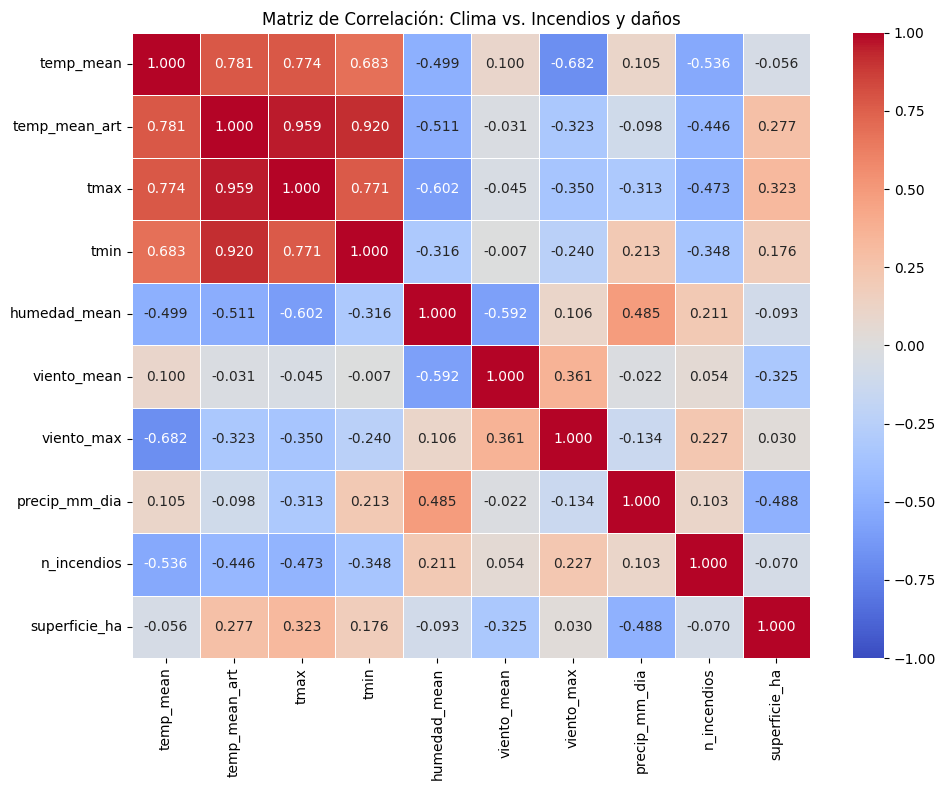

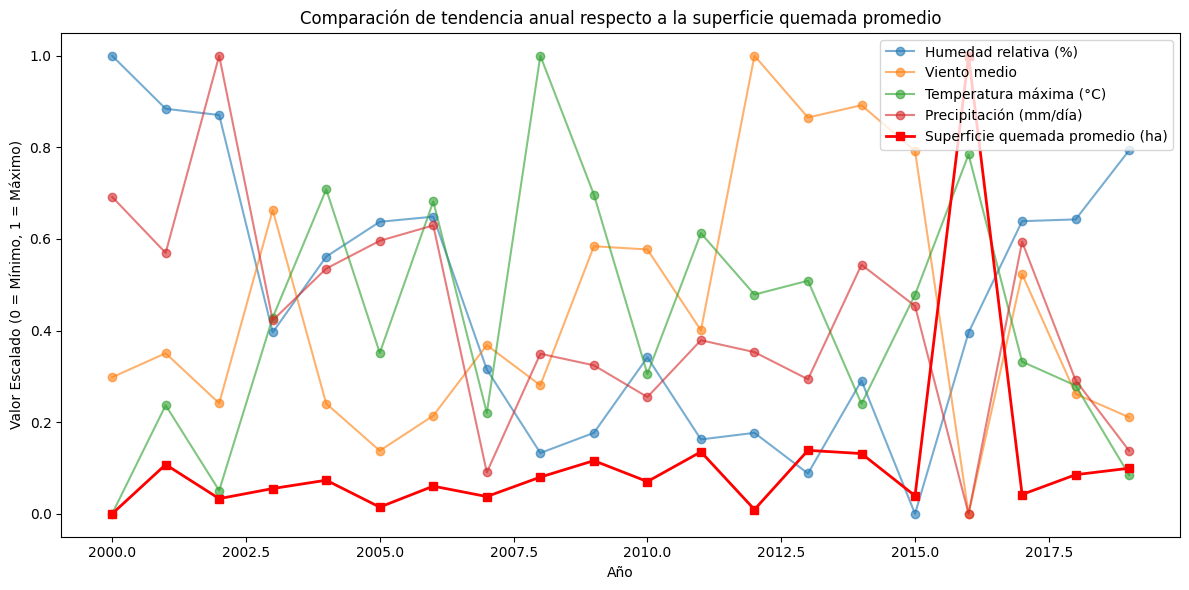

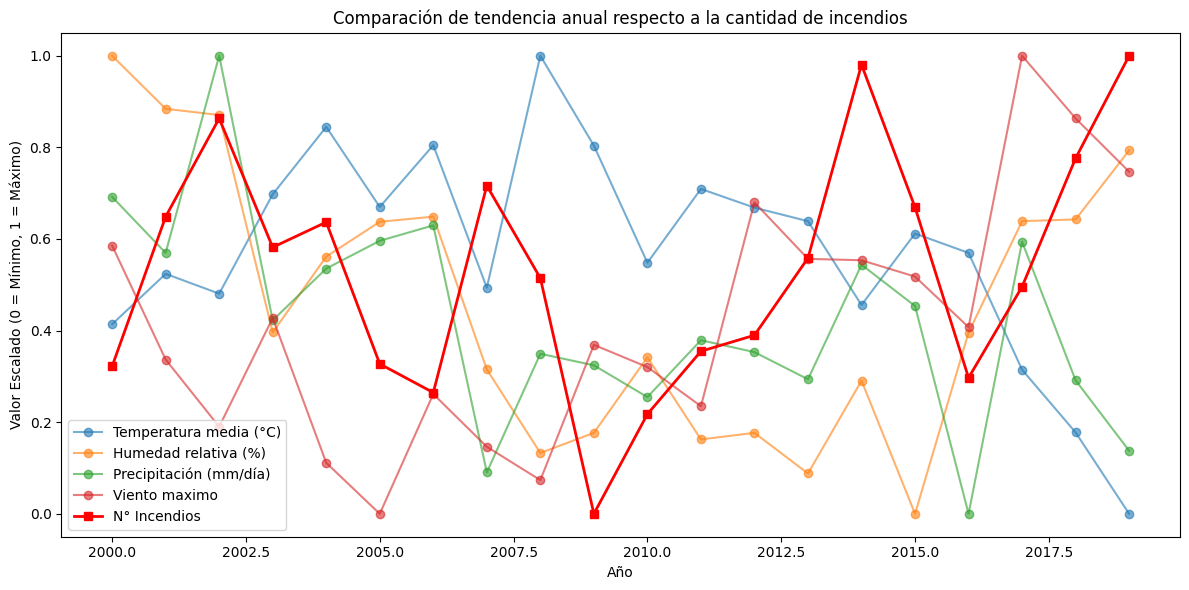

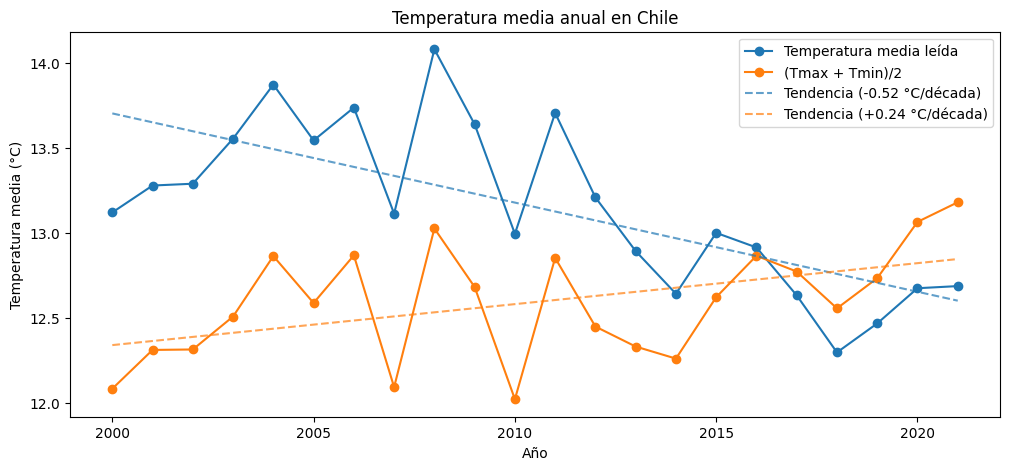

#3.- Preguntas relevantes
A raiz de la exploracion hecha de los datos, se proponen las siguientes preguntas enfocadas en distintos tipos de metodos para analizar y tratar de responder al motivo por el cual se eligio el tema. Además, se acompañan de los supuestos que nos hicieron interesarnos en las mismas y las hipótesis que tenemos ante cada una.

**1.** ¿Es posible predecir la superficie quemada mensual de una región a partir de variables meteorológicas  de este mes, de meses pasados y datos históricos anuales?
(Regresión en aprendizaje supervisado)

*El interés de esta pregunta va en poder predecir los incendios y su intensidad. Así se espera se pudiese tomar acciones preventivas con antelación como instalación de cortafuegos y rutas para la llegada de bomberos ante posibles eventualidades. Nuestra hipótesis es que en los meses con menor precipitación acumulada y mayor temperatura (considerando meses previos), se haya propensión a una mayor superficie quemada.*


**2.**¿Qué meses se comportan atípicamente con respecto a variables históricas? &
¿Coinciden con incendios detectados?
(Cluster, aprendizaje no supervisado. & Clasificación binaria)

*Queremos revisar si hay un comportamiento habitual anual entre los meses del año, asumiendo su existencia pensamos en buscar outliers y buscar sus causas o consecuencias.Un par de ideas ejemplo que tenemos en mente es revisar si el comportamiento de humedad y otras variables climaticas pueden cambiar una vez ocurrido un incendio forestal (imaginando una disminución de la vgetación que retiene la humedad). Igualmente, si por ejemplo puede darse que ante un outlier de un invierno muy seco esto puede incrementar la posibilidad de incendios forestales catastróficos en el verano. Nuestra hipótesis entonces consiste en que en los meses climáticamente atípicos, en especial los más secos y cálidos, coinciden con una mayor probabilidad de incendios por ocurrir (Cuando hay vegetación seca consecuencia de la sequía es más sencilla la propagación de incendios) o ya ocurridos (la falta de humedad también es consecuencia de falta de vegetación).*

**3.** ¿Es posible clasificar en periodos y regiones situaciones de alto riesgo de incendio? ¿Qué  variable meteorológicas tiene un mayor peso en la predicción de incendios?
(Clasificación, aprendizaje supervisado.)
*Ya contamos con la hipótesis de que veremos que los veranos son periodos de alto riesgo. En ello queremos ver qué variables son las culpables de está causalidad y su peso. Nuestra hipótesis por revisar es que sí se puede hacer la clasificación, y la temperatura máxima y la precipitación acumulada son las variables con mayor peso a la hora de anticipar incendios.*


# 4.- Contribución

# 6.- Uso de IA

# 6.- Bibliografía y reconocimiento

## Referencias

Centro de Investigación para la Gestión Integrada del Riesgo de Desastres. (2024, 26 de febrero). *Informe revela el alcance de los impactos causados por incendios en Viña del Mar*. https://cigiden.cl/informe-revela-el-alcance-de-los-impactos-causados-por-incendios-en-vina-del-mar/

Corporación Nacional Forestal. (2024). *Estadísticas históricas de incendios forestales en Chile, 1964–2024* [Conjunto de datos]. https://www.conaf.cl/

Dirección Meteorológica de Chile. (s.f.). *Datos de temperatura, humedad relativa, viento y precipitación* [Conjunto de datos]. Observatorio de Cambio Climático, Ministerio de Ciencia, Tecnología, Conocimiento e Innovación. https://github.com/MinCiencia/Datos-CambioClimatico

NASA. (s.f.). *Fire Information for Resource Management System (FIRMS)* [Conjunto de datos]. Land, Atmosphere Near real-time Capability for Earth observation (LANCE), Earth Science Data and Information System (ESDIS). https://firms.modaps.eosdis.nasa.gov/

NASA LANCE FIRMS. (2021). *MODIS Collection 6.1 NRT hotspot / active fire detections MCD14DL* [Conjunto de datos]. https://doi.org/10.5067/FIRMS/MODIS/MCD14DL.NRT.0061

NASA VIIRS Land Science Team. (2020a). *VIIRS NOAA-20 (JPSS-1) 375m, I-Band active fire product NRT (vector data)* [Conjunto de datos]. NASA LANCE MODIS at the MODAPS. https://doi.org/10.5067/FIRMS/VIIRS/VJ114IMGT_NRT.002

NASA VIIRS Land Science Team. (2020b). *VIIRS (S-NPP) I Band 375 m active fire product NRT (vector data)* [Conjunto de datos]. NASA LANCE MODIS at the MODAPS. https://doi.org/10.5067/FIRMS/VIIRS/VNP14IMGT_NRT.002

NASA VIIRS Land Science Team. (2024). *VIIRS (NOAA-21/JPSS-2) I Band 375 m active fire product NRT (vector data)* [Conjunto de datos]. NASA LANCE MODIS at the MODAPS. https://doi.org/10.5067/VIIRS/VJ214IMGTDL_NRT.002

Schroeder, W., Oliva, P., Giglio, L., & Csiszar, I. A. (2014). The New VIIRS 375 m active fire detection data product: Algorithm description and initial assessment. *Remote Sensing of Environment, 143*, 85–96. https://doi.org/10.1016/j.rse.2013.12.008

## Reconocimiento

Se reconoce el uso de datos de NASA FIRMS, distribuidos por el sistema LANCE (https://earthdata.nasa.gov/lance), parte del Earth Science Data and Information System (ESDIS) de NASA.